# BayesFlow + SIR Inference + R0 Posterior

1. simulate noisy infected-fraction trajectories from an SIR model,
2. train a BayesFlow posterior estimator for `beta` and `gamma`,
3. derive the posterior of `R0 = beta / gamma`,
4. visualize and interpret the posterior results.

## VS Code + Colab note



In [ ]:

%pip install -q bayesflow==2.0.9 numpy==1.26.4 pandas==2.3.3 scipy==1.15.3 matplotlib==3.8.4 seaborn

In [ ]:
import os
import warnings
from importlib import metadata


# 检查版本并设置环境变量
warnings.filterwarnings("ignore")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp

try:
    import tensorflow as tf
    import keras
    import bayesflow as bf
except Exception as e:
    raise RuntimeError(
        "Import failed. If you just ran the %pip install cell in VS Code or Colab, please restart the kernel and then rerun this cell. Original error: "
        + repr(e)
    )

expected_versions = {
    "bayesflow": "2.0.9",
    "tensorflow": "2.17.0",
    "keras": "3.13.2",
    "numpy": "1.26.4",
    "pandas": "2.3.3",
    "scipy": "1.15.3",
    "matplotlib": "3.8.4",
}

for pkg, expected in expected_versions.items():
    current = metadata.version(pkg)
    print(f"{pkg}: {current}")
    if current != expected:
        print(f"  warning: expected {expected}, but found {current}")

np.random.seed(42)
keras.utils.set_random_seed(42)
sns.set_theme(style="whitegrid", context="notebook")

print("BayesFlow backend ready.")

INFO:bayesflow:Using backend 'tensorflow'


bayesflow: 2.0.9
tensorflow: 2.17.0
keras: 3.13.2
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.15.3
matplotlib: 3.8.4
BayesFlow backend ready.


## Model setup

- Unknown parameters: `beta`, `gamma`
- Derived quantity: `R0 = beta / gamma`
- Observation: noisy infected-fraction time series
- Summary network: `time_series_network`
- Inference network: `coupling_flow`

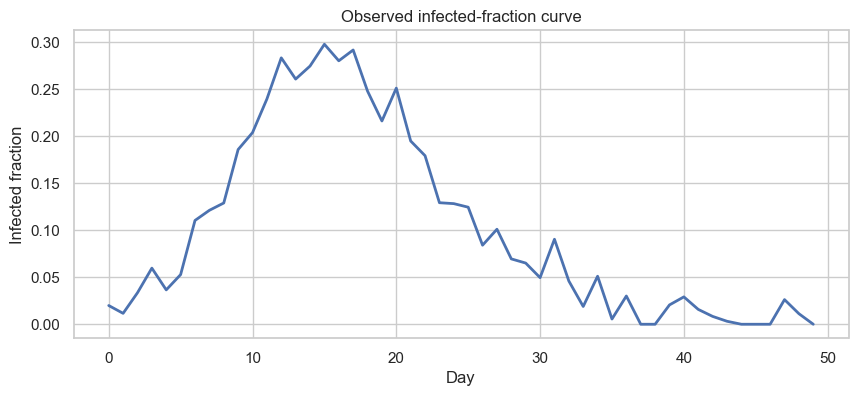

True beta: 0.55
True gamma: 0.18
True R0: 3.056


In [2]:
N_DAYS = 50
TIME_GRID = np.arange(N_DAYS)
I0 = 0.01
R0_INIT = 0.0
S0 = 1.0 - I0 - R0_INIT
OBS_NOISE = 0.02

PRIOR_BOUNDS = {
    "beta": (0.10, 1.00),
    "gamma": (0.05, 0.50),
}


def sir_rhs(t, y, beta, gamma):
    s, i, r = y
    ds = -beta * s * i
    di = beta * s * i - gamma * i
    dr = gamma * i
    return [ds, di, dr]


def solve_sir(beta, gamma, n_days=N_DAYS):
    sol = solve_ivp(
        lambda t, y: sir_rhs(t, y, beta, gamma),
        (0, n_days - 1),
        [S0, I0, R0_INIT],
        t_eval=np.arange(n_days),
        rtol=1e-6,
        atol=1e-8,
    )
    return sol.y.T


def simulate_curve(beta, gamma):
    infected = solve_sir(beta, gamma)[:, 1]
    obs = infected + np.random.normal(0.0, OBS_NOISE, size=infected.shape)
    obs = np.clip(obs, 0.0, 1.0)
    return obs[:, None].astype("float32")


def sim_one():
    beta = np.random.uniform(*PRIOR_BOUNDS["beta"])
    gamma = np.random.uniform(*PRIOR_BOUNDS["gamma"])
    return {
        "beta": np.array([beta], dtype="float32"),
        "gamma": np.array([gamma], dtype="float32"),
        "obs": simulate_curve(beta, gamma),
    }


true_beta = 0.55
true_gamma = 0.18
true_r0 = true_beta / true_gamma
observed_curve = simulate_curve(true_beta, true_gamma)

plt.figure(figsize=(10, 4))
plt.plot(TIME_GRID, observed_curve[:, 0], lw=2)
plt.xlabel("Day")
plt.ylabel("Infected fraction")
plt.title("Observed infected-fraction curve")
plt.show()

print("True beta:", true_beta)
print("True gamma:", true_gamma)
print("True R0:", round(true_r0, 3))

In [3]:
simulator = bf.make_simulator(sim_one)

workflow = bf.BasicWorkflow(
    simulator=simulator,
    inference_variables=["beta", "gamma"],
    summary_variables=["obs"],
    summary_network="time_series_network",
    inference_network="coupling_flow",
)

workflow.approximator.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4)
)

print("BayesFlow workflow ready.")

BayesFlow workflow ready.


INFO:bayesflow:Building dataset from simulator instance of LambdaSimulator.


INFO:bayesflow:Building on a test batch.


Epoch 1/12


60/60 - 17s - 284ms/step - loss: 2.3038


Epoch 2/12


...

60/60 - 5s - 87ms/step - loss: -1.2475e+00


Epoch 11/12


60/60 - 5s - 84ms/step - loss: -1.3144e+00


Epoch 12/12


60/60 - 5s - 83ms/step - loss: -1.3927e+00


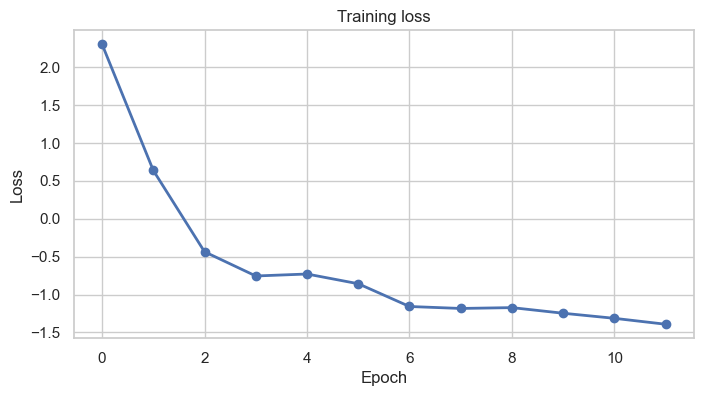

In [4]:
# Increase epochs and num_batches if you want a tighter posterior.
history = workflow.approximator.fit(
    simulator=simulator,
    epochs=12,
    batch_size=32,
    num_batches=60,
    workers=1,
    verbose=2,
)

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], marker="o", lw=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

In [5]:
samples = workflow.sample(
    num_samples=4000,
    conditions={"obs": observed_curve[None, ...]},
    split=True,
    batch_size=1,
)

posterior_df = pd.DataFrame({
    "beta": np.asarray(samples["beta"]).reshape(-1),
    "gamma": np.asarray(samples["gamma"]).reshape(-1),
})
posterior_df["R0"] = posterior_df["beta"] / posterior_df["gamma"]

summary_table = posterior_df[["beta", "gamma", "R0"]].describe(percentiles=[0.05, 0.5, 0.95]).T
summary_table = summary_table[["mean", "std", "5%", "50%", "95%"]]
summary_table

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 0.42 seconds.


,mean,std,5%,50%,95%
beta,0.561686,0.011301,0.542796,0.561792,0.580151
gamma,0.198701,0.006264,0.188523,0.198617,0.209154
R0,2.828906,0.085098,2.692357,2.826510,2.974811


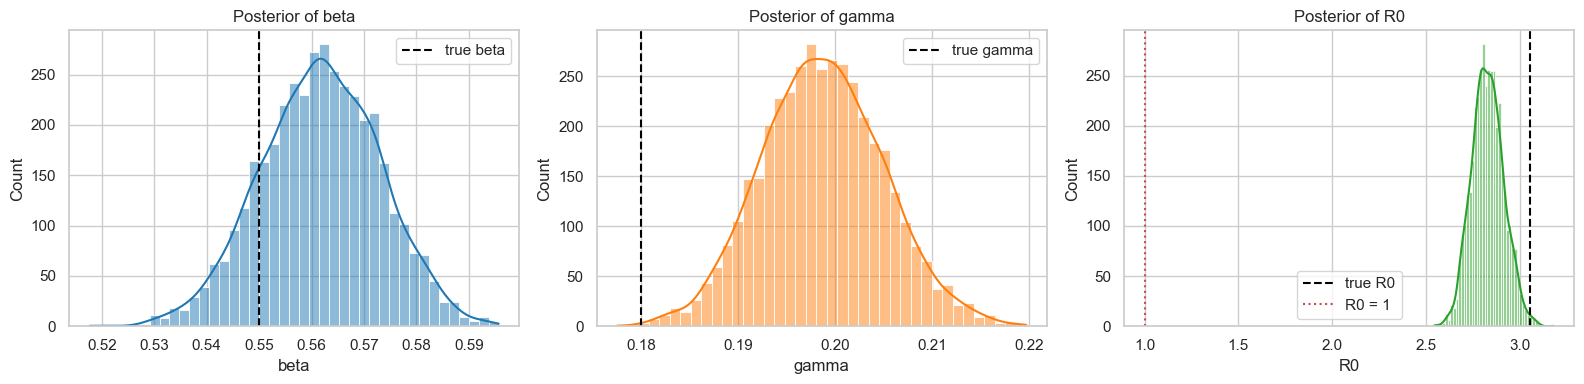

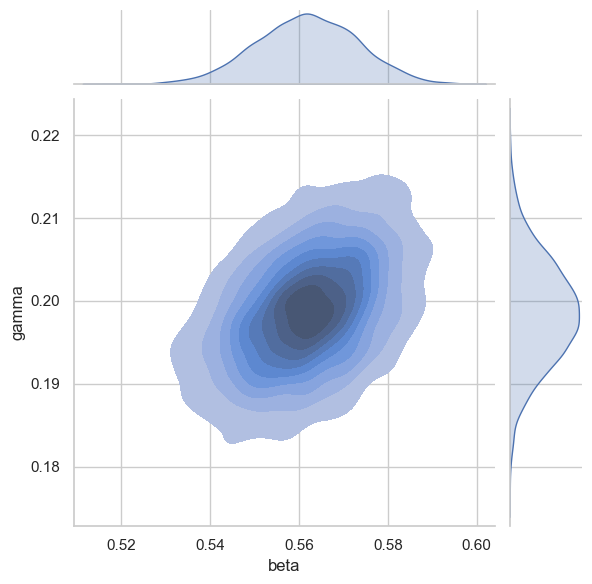

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(posterior_df["beta"], kde=True, ax=axes[0], color="#1f77b4")
axes[0].axvline(true_beta, color="black", linestyle="--", label="true beta")
axes[0].set_title("Posterior of beta")
axes[0].legend()

sns.histplot(posterior_df["gamma"], kde=True, ax=axes[1], color="#ff7f0e")
axes[1].axvline(true_gamma, color="black", linestyle="--", label="true gamma")
axes[1].set_title("Posterior of gamma")
axes[1].legend()

sns.histplot(posterior_df["R0"], kde=True, ax=axes[2], color="#2ca02c")
axes[2].axvline(true_r0, color="black", linestyle="--", label="true R0")
axes[2].axvline(1.0, color="#c44e52", linestyle=":", label="R0 = 1")
axes[2].set_title("Posterior of R0")
axes[2].legend()

plt.tight_layout()
plt.show()

sns.jointplot(data=posterior_df, x="beta", y="gamma", kind="kde", fill=True)
plt.show()

In [7]:
r0_ci = np.quantile(posterior_df["R0"], [0.05, 0.5, 0.95])
prob_r0_gt_1 = float((posterior_df["R0"] > 1.0).mean())

print(f"True R0: {true_r0:.3f}")
print(f"Posterior median R0: {r0_ci[1]:.3f}")
print(f"Posterior 90% interval for R0: [{r0_ci[0]:.3f}, {r0_ci[2]:.3f}]")
print(f"Posterior probability R0 > 1: {prob_r0_gt_1:.4f}")

True R0: 3.056
Posterior median R0: 2.827
Posterior 90% interval for R0: [2.692, 2.975]
Posterior probability R0 > 1: 1.0000


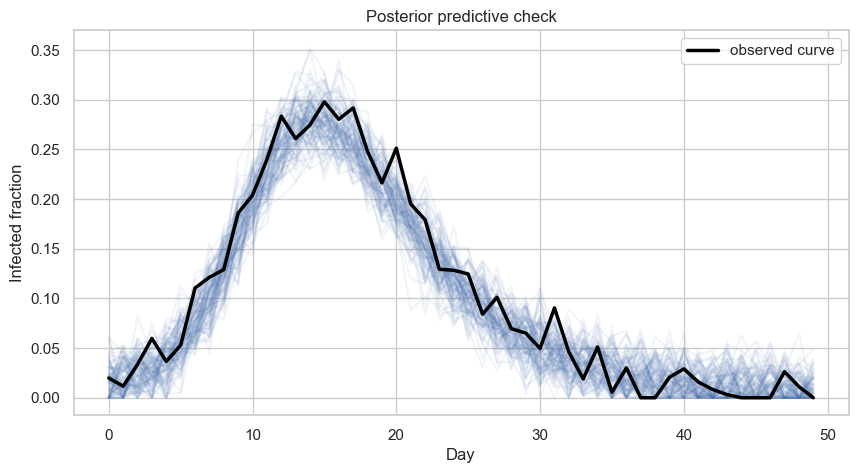

In [8]:
n_ppc = 100
draw_ids = np.random.choice(len(posterior_df), size=n_ppc, replace=False)
ppc_draws = posterior_df.iloc[draw_ids][["beta", "gamma"]].to_numpy()
ppc_curves = np.stack([simulate_curve(beta, gamma)[:, 0] for beta, gamma in ppc_draws], axis=0)

plt.figure(figsize=(10, 5))
for curve in ppc_curves:
    plt.plot(TIME_GRID, curve, color="#4c72b0", alpha=0.08)
plt.plot(TIME_GRID, observed_curve[:, 0], color="black", lw=2.5, label="observed curve")
plt.xlabel("Day")
plt.ylabel("Infected fraction")
plt.title("Posterior predictive check")
plt.legend()
plt.show()

## Result

- 如果 `beta` 和 `gamma` 的后验分布比较集中，并且中心位置接近真实值，说明推断效果较好。
- 如果 `R0` 的后验质量主要集中在 `1` 以上，说明模型支持疫情处于扩张传播阶段。
- 如果后验预测曲线与观测曲线重合较好，说明当前后验在行为层面上是合理的。
- 如果想让后验分布更稳定、更尖锐，可以继续增加 `epochs`、`num_batches`，或者适当降低观测噪声。